# FEM for submerged tunnel as 3D beams

In [1]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time
from scipy.optimize import fsolve

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass

## Visualize the tunnel

- Radius = 2683 m
- Distance between landings = 3700 m
- Angular span = [68.2 deg, 111.8 deg]

Elements per tube      : 881
Nodes per tube         : 882
Actual element length  : 12.498 m


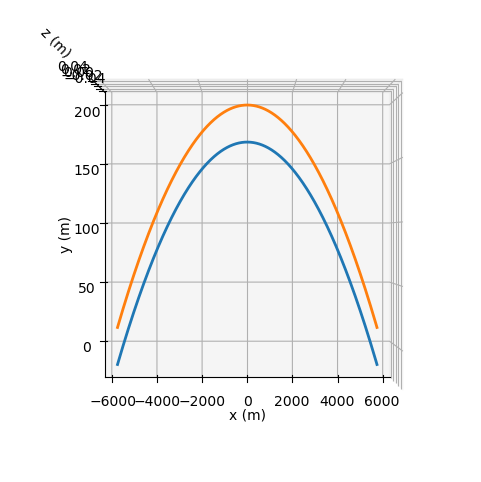

Total nodes (both tubes): 1764


In [2]:
TunRad = 84118  # m
TunAng = (90 + 7.5/2, 90 - 7.5/2)  # deg

Le = 12.5  # desired element length [m]

# Compute number of elements from target element length
arc_angle_deg = abs(TunAng[0] - TunAng[1])
arc_length = TunRad * np.deg2rad(arc_angle_deg)

nEle = int(round(arc_length / Le))
actual_Le = arc_length / nEle

theta = np.linspace(
    np.deg2rad(TunAng[0]),
    np.deg2rad(TunAng[1]),
    nEle + 1
)

print(f"Elements per tube      : {nEle}")
print(f"Nodes per tube         : {nEle + 1}")
print(f"Actual element length  : {actual_Le:.3f} m")

# --------------------------------------------------
# Tube 1
# --------------------------------------------------

TunCX = TunRad * np.cos(theta)
TunCY = TunRad * np.sin(theta)
TunCY = TunCY - np.min(TunCY) - 15
TunCZ = np.zeros_like(TunCX)

# --------------------------------------------------
# Tube 2
# --------------------------------------------------

TunCX2 = TunRad * np.cos(theta)
TunCY2 = TunRad * np.sin(theta)
TunCY2 = TunCY2 - np.min(TunCY2) + 15
TunCZ2 = np.zeros_like(TunCX2)

# --------------------------------------------------
# Plot geometry
# --------------------------------------------------

fig = plt.figure()
ax = plt.axes(projection='3d')

ax.view_init(90, 270)
ax.plot(TunCX, TunCY, TunCZ, lw=2)
ax.plot(TunCX2, TunCY2, TunCZ2, lw=2)

ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('z (m)')
plt.grid(True)
plt.show()

# --------------------------------------------------
# Combine both tubes into one coordinate set
# --------------------------------------------------

TunCX = np.append(TunCX, TunCX2)
TunCY = np.append(TunCY, TunCY2)
TunCZ = np.append(TunCZ, TunCZ2)

nNodess = len(TunCX)

print(f"Total nodes (both tubes): {nNodess}")

## Properties of Beam

In [3]:
Beam_GJ = 9.5e12                 # [N.m2]
Beam_Im = 1.5e6                      #[kg.m]
Beam_m = 1.1e5                  # [kg/m]
Beam_EIy = 141193e9               # [N.m2]
Beam_EIz = 141193e9               # [N.m2]
Beam_EA = 15.5*39e9              # [N]


# Connector is 6 meters wide and 5.5 meters high, with a thickness of 0.5 meters. So inner area is 5 meters wide and 4.5 meters high
# The connector is made of the same material as the tunnel, which has a Young's modulus of 39 GPa. 
# The mass per meter of the connector is calculated based on its volume and the density of the material, which is assumed to be 2600 kg/m3.

E = 39e9                                  # Pa, Young's modulus of reinforced concrete
G = 16.3e9                                 # Pa, shear modulus of reinforced concrete
h_out = 6                                  # m, outer diameter of the connector
h_in = 5                                  # m, inner diameter of the connector
w_out = 5.5                                # m, outer width of the connector
w_in = 4.5                                # m, inner width of the connector
t=0.5
hm = 6-t
bm = 5.5-t
Am = hm*bm
pm = 2*(hm+bm)                                                  # m, perimeter of the connector cross-section
Concrete_density = 2600                                         # kg/m3, density of reinforced concrete
TunArea = 6*5.5 - 5*4.5                                         # m2, cross-sectional area of the connector
connector_GJ = G*(2*t**2 * bm**2 * hm**2/(bm+hm))                                 # [N.m2]
connector_Im = 2600* (bm**2 + hm**2)**2 * bm*hm*t / 144         #[kg.m] (Volgens mij hoort dit niet zo)
connector_m =  (TunArea) *2600                                  # [kg/m]
connector_EIy = 1/12 * (w_out**3*h_out - w_in**3*h_in) * E      # [N.m2]
connector_EIz = 1/12 * (w_out*h_out**3 - w_in*h_in**3) * E      # [N.m2]
connector_EA = (6 * 5.5 - 5 * 4.5) * E     # [N]
# connector_GJ = 2.12e13 / 2                 # [N.m2]
# connector_Im = 1.17e6 / 2                     #[kg.m]
# connector_m = 248609 / 2               # [kg/m]
# connector_EIy = 141193e9 / 2               # [N.m2]
# connector_EIz = 141193e9 / 2                   # [N.m2]
# connector_EA = (6 * 5 - 5.5 * 4.5) * 39e9     # [N]



print("Torsional rigidity (GJ) "f"{Beam_GJ:.2}"" N.m2")
print("Mass moment of inertia (Im) "f"{Beam_Im:.2}"" kg.m")
print("Mass per meter "f"{Beam_m}"" kg/m")
print("Flexural rigidity (EI_y) "f"{Beam_EIy:.2}"" N.m2")
print("Flexural rigidity (EI_z) "f"{Beam_EIz:.2}"" N.m2")
print("Axial rigidity (EA)" f"{Beam_EA:.2}" " N")

print("-" * 50)

print("Torsional rigidity connector (GJ) "f"{connector_GJ:.2}"" N.m2")
print("Mass moment of inertia connector (Im) "f"{connector_Im:.2}"" kg.m")
print("Mass per meter connector "f"{connector_m}"" kg/m")
print("Flexural rigidity connector (EI_y) "f"{connector_EIy:.2}"" N.m2")
print("Flexural rigidity connector (EI_z) "f"{connector_EIz:.2}"" N.m2")
print("Axial rigidity connector (EA)" f"{connector_EA:.2}" " N")



# Beam_m = 1.28e5                  # [kg/m]
# Beam_EI_y = 1.89e13                 # [N.m2]
# Beam_EI_z = 1.89e13                 # [N.m2]
# Beam_EA = 1.08e12                 # [N]
# Beam_GJ = 1.45e13                 # [N.m2]
# Beam_Im = 30                      #[kg.m]

Torsional rigidity (GJ) 9.5e+12 N.m2
Mass moment of inertia (Im) 1.5e+06 kg.m
Mass per meter 110000.0 kg/m
Flexural rigidity (EI_y) 1.4e+14 N.m2
Flexural rigidity (EI_z) 1.4e+14 N.m2
Axial rigidity (EA)6e+11 N
--------------------------------------------------
Torsional rigidity connector (GJ) 5.9e+11 N.m2
Mass moment of inertia connector (Im) 7.6e+05 kg.m
Mass per meter connector 27300.0 kg/m
Flexural rigidity connector (EI_y) 1.8e+12 N.m2
Flexural rigidity connector (EI_z) 2e+12 N.m2
Axial rigidity connector (EA)4.1e+11 N


## Mesh setup

In [4]:
# # -----------------------------
# # Nodes
# # -----------------------------
# NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]
# nNodessssssss = len(NodeC)

# nodeDiff = int(round(nNode / 2))

# if nNode != 2 * nodeDiff:
#     raise ValueError("The model expects the two tunnel tubes to have the same number of nodes.")

# # -----------------------------
# # Tunnel elements
# # -----------------------------
# Ele_tunnel_1 = [
#     [n1, n1 + 1, Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
#     for n1 in range(0, nodeDiff - 1)
# ]

# Ele_tunnel_2 = [
#     [nodeDiff + n1, nodeDiff + n1 + 1, Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
#     for n1 in range(0, nodeDiff - 1)
# ]

# # -----------------------------
# # Escape-route elements every 250 m
# # -----------------------------
# escape_spacing = 250.0  # [m]

# NodeArr = np.array(NodeC, dtype=float)
# tube1 = NodeArr[:nodeDiff]

# segment_lengths = np.linalg.norm(np.diff(tube1, axis=0), axis=1)
# s = np.insert(np.cumsum(segment_lengths), 0, 0.0)

# target_s = np.arange(0.0, s[-1] + 1e-9, escape_spacing)

# escape_nodes = []

# for target in target_s:
#     i = np.searchsorted(s, target)

#     if i >= len(s):
#         i = len(s) - 1

#     escape_nodes.append(i)

# escape_nodes = np.array(escape_nodes, dtype=int)

# # Optional: uncomment if you do NOT want escape routes at the two ends
# # escape_nodes = escape_nodes[1:-1]

# Ele_escape = [
#     [i, i + nodeDiff, connector_m, connector_EA, connector_EIy, connector_EIz, connector_GJ, connector_Im]
#     for i in escape_nodes   
# ]

# # -----------------------------
# # Combine all elements
# # -----------------------------
# Ele = np.array(Ele_tunnel_1 + Ele_tunnel_2 + Ele_escape, dtype=float)
# nEle = len(Ele)

# # -----------------------------
# # Print checks
# # -----------------------------
# print("Number of nodes =", nNode)
# print("Number of tunnel elements =", len(Ele_tunnel_1) + len(Ele_tunnel_2))
# print("Number of escape-route elements =", len(Ele_escape))
# print("Number of elements =", nEle)

# print("Escape-route node indices on tunnel 1:")
# print(escape_nodes)

# print("Escape-route distances along tunnel:")
# print(s[escape_nodes])

# print("Actual escape-route spacing:")
# print(np.diff(s[escape_nodes]))

# print("Mean tunnel mesh spacing =", np.mean(segment_lengths), "m")
# print("Mean escape-route spacing =", np.mean(np.diff(s[escape_nodes])), "m")

In [5]:
# -----------------------------
# Nodes
# -----------------------------
NodeC = [[x, y, z] for x, y, z in zip(TunCX, TunCY, TunCZ)]
nNodes = len(NodeC)

nodeDiff = int(round(nNodes / 2))

if nNodes != 2 * nodeDiff:
    raise ValueError("The model expects two equal tunnel tubes.")

# -----------------------------
# Tunnel elements
# -----------------------------
Ele_tunnel_1 = [
    [n1, n1 + 1, Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
    for n1 in range(0, nodeDiff - 1)
]

Ele_tunnel_2 = [
    [nodeDiff + n1, nodeDiff + n1 + 1,
     Beam_m, Beam_EA, Beam_EIy, Beam_EIz, Beam_GJ, Beam_Im]
    for n1 in range(0, nodeDiff - 1)
]

# -----------------------------
# Escape-route elements every 250 m
# -----------------------------
escape_spacing = 250.0

NodeArr = np.array(NodeC, dtype=float)
tube1 = NodeArr[:nodeDiff]

segment_lengths = np.linalg.norm(np.diff(tube1, axis=0), axis=1)
s = np.insert(np.cumsum(segment_lengths), 0, 0.0)

target_s = np.arange(0.0, s[-1] + 0.5 * escape_spacing, escape_spacing)

escape_nodes = np.unique([
    int(np.argmin(np.abs(s - target)))
    for target in target_s
])

# Optional: remove end connectors
escape_nodes = escape_nodes[1:-1]

Ele_escape = [
    [i, i + nodeDiff,
     connector_m, connector_EA, connector_EIy, connector_EIz,
     connector_GJ, connector_Im]
    for i in escape_nodes
]

Ele = np.array(Ele_tunnel_1 + Ele_tunnel_2 + Ele_escape, dtype=float)
nEle = len(Ele)

print("Number of nodes =", nNodes)
print("Number of tunnel elements =", len(Ele_tunnel_1) + len(Ele_tunnel_2))
print("Number of escape-route elements =", len(Ele_escape))
print("Number of elements =", nEle)

print("Escape-route node indices on tunnel 1:")
print(escape_nodes)

print("Escape-route distances along tunnel:")
print(s[escape_nodes])

print("Actual escape-route spacing:")
print(np.diff(s[escape_nodes]))

print("Mean tunnel mesh spacing =", np.mean(segment_lengths), "m")
print("Mean escape-route spacing =", np.mean(np.diff(s[escape_nodes])), "m")

Number of nodes = 1764
Number of tunnel elements = 1762
Number of escape-route elements = 43
Number of elements = 1805
Escape-route node indices on tunnel 1:
[ 20  40  60  80 100 120 140 160 180 200 220 240 260 280 300 320 340 360
 380 400 420 440 460 480 500 520 540 560 580 600 620 640 660 680 700 720
 740 760 780 800 820 840 860]
Escape-route distances along tunnel:
[  249.96641183   499.93282367   749.8992355    999.86564734
  1249.83205917  1499.79847101  1749.76488284  1999.73129468
  2249.69770651  2499.66411835  2749.63053018  2999.59694202
  3249.56335385  3499.52976568  3749.49617752  3999.46258935
  4249.42900119  4499.39541302  4749.36182486  4999.32823669
  5249.29464853  5499.26106036  5749.2274722   5999.19388403
  6249.16029587  6499.1267077   6749.09311954  6999.05953137
  7249.0259432   7498.99235504  7748.95876687  7998.92517871
  8248.89159054  8498.85800238  8748.82441421  8998.79082605
  9248.75723788  9498.72364972  9748.69006155  9998.65647339
 10248.62288522 104

Listing the nodes and elements. <br>
Plot the mesh setup for reference.

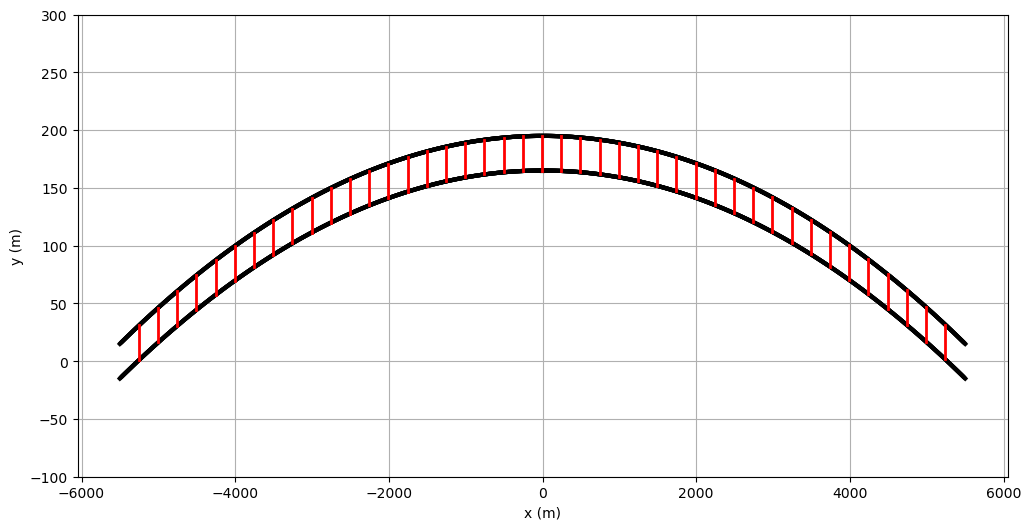

In [6]:
plt.figure(figsize=(12,6))

# -----------------------------
# Plot tunnel arches
# -----------------------------
for ele in Ele_tunnel_1 + Ele_tunnel_2:

    n1 = int(ele[0])
    n2 = int(ele[1])

    x1, y1, _ = NodeC[n1]
    x2, y2, _ = NodeC[n2]

    plt.plot(
        [x1, x2],
        [y1, y2],
        lw=3,
        color='k'
    )

# -----------------------------
# Plot escape routes
# -----------------------------
for ele in Ele_escape:

    n1 = int(ele[0])
    n2 = int(ele[1])

    x1, y1, _ = NodeC[n1]
    x2, y2, _ = NodeC[n2]

    plt.plot(
        [x1, x2],
        [y1, y2],
        lw=2,
        color='r'   # different color helps visualization
    )

# -----------------------------
# Formatting
# -----------------------------
plt.ylim(-100, 300)
plt.grid(True)

plt.xlabel('x (m)')
plt.ylabel('y (m)')

plt.show()

In [7]:
mooring_spacing = 25.0  # [m] 12.5, 6.25, 50, 100

NodeArr = np.array(NodeC, dtype=float)
nodeDiff = int(nNodes / 2)

# Use tube 1 to determine positions along the tunnel
tube1 = NodeArr[:nodeDiff]

# Arc length along the tunnel
segment_lengths = np.linalg.norm(np.diff(tube1, axis=0), axis=1)
s = np.insert(np.cumsum(segment_lengths), 0, 0.0)

# Desired mooring positions every 25 m
target_s = np.arange(0.0, s[-1] + 0.5 * mooring_spacing, mooring_spacing)

# Find nearest FEM node to each mooring position
mooring_nodes_tube1 = np.unique([
    int(np.argmin(np.abs(s - target)))
    for target in target_s
])

# Optional: remove end nodes if they are already supported
mooring_nodes_tube1 = mooring_nodes_tube1[1:-1]

# Corresponding nodes on tube 2
mooring_nodes_tube2 = mooring_nodes_tube1 + nodeDiff

print("Mooring nodes tube 1:", mooring_nodes_tube1)
print("Mooring nodes tube 2:", mooring_nodes_tube2)
print("Number of moorings per tube:", len(mooring_nodes_tube1))
print("Number of moorings per tube:", len(mooring_nodes_tube2))

Mooring nodes tube 1: [  2   4   6   8  10  12  14  16  18  20  22  24  26  28  30  32  34  36
  38  40  42  44  46  48  50  52  54  56  58  60  62  64  66  68  70  72
  74  76  78  80  82  84  86  88  90  92  94  96  98 100 102 104 106 108
 110 112 114 116 118 120 122 124 126 128 130 132 134 136 138 140 142 144
 146 148 150 152 154 156 158 160 162 164 166 168 170 172 174 176 178 180
 182 184 186 188 190 192 194 196 198 200 202 204 206 208 210 212 214 216
 218 220 222 224 226 228 230 232 234 236 238 240 242 244 246 248 250 252
 254 256 258 260 262 264 266 268 270 272 274 276 278 280 282 284 286 288
 290 292 294 296 298 300 302 304 306 308 310 312 314 316 318 320 322 324
 326 328 330 332 334 336 338 340 342 344 346 348 350 352 354 356 358 360
 362 364 366 368 370 372 374 376 378 380 382 384 386 388 390 392 394 396
 398 400 402 404 406 408 410 412 414 416 418 420 422 424 426 428 430 432
 434 436 438 440 442 444 446 448 450 452 454 456 458 460 462 464 466 468
 470 472 474 476 478 480 482 

## Define the shape functions

Here we will use **linear** shape functions for the **axial displacement** and **cubic** shape functions for the **deflection and rotations**. Since we already know its expression and we already have the value of the elemental matrices, we skip this step in this tutorial. 

## Computation of the elemental matrices

In the theory we have seen that the mass and stiffness elemental matrices for the space frame using linear and cubic shape functions are given by:

| <img width="50%" src="./img/nb09_f01_3Ddofs_nptel.png" /> |
| :---- |
| Fig 1: Definition of 3 dofs per node, for the 2 noded elements. (This is from my lectures slides. To Be replaced) |

$$ M = \frac{mL}{420} 
\begin{bmatrix} 
140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 156 & 0 & 0 & 0 & 22L & 0 & 54 & 0 & 0 & 0 & -13L \\ 
0 & 0 & 156 & 0 & 22L & 0 & 0 & 0 & 54 & 0 & 13L & 0 \\ 
0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 \\ 
0 & 0 & 22L & 0 & 4L^2 & 0 & 0 & 0 & -13L & 0 & -3L^2 & 0 \\ 
0 & 22L & 0 & 0 & 0 & 4L^2 & 0 & 13L & 0 & 0 & 0 & -3L^2 \\ 
70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 54 & 0 & 0 & 0 & 13L & 0 & 156 & 0 & 0 & 0 & -22L \\ 
0 & 0 & 54 & 0 & -13L & 0 & 0 & 0 & 156 & 0 & 22L & 0 \\ 
0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 \\ 
0 & 0 & 13L & 0 & -3L^2 & 0 & 0 & 0 & 22L & 0 & 4L^2 & 0 \\
0 & -13L & 0 & 0 & 0 & -3L^2 & 0 & -22L & 0 & 0 & 0 & 4L^2
\end{bmatrix} $$
$$ \quad K = 
\begin{bmatrix} 
\frac{EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{-EA}{L} &  0 & 0 & 0 & 0 & 0\\ 
0 & \frac{12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{-12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} \\ 
0 & 0 & \frac{12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{-12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & \frac{-6EI}{L^2} & 0 & \frac{4EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L} & 0 & \frac{-6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} \\ 
\frac{-EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{EA}{L} & 0 & 0 & 0 & 0 & 0 \\ 
0 & -\frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} \\ 
0 & 0 & -\frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{4EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L}
\end{bmatrix}$$

These matrices are used directly when calling the `BeamMatrices` function within the assembly process.

## Global assembly

The last step is to compute the global matrices and the global forcing vector. We start by initializing the global matrices as 1-dimensional arrays.

Then we loop over elements and perform all the elemental operations.

In [8]:
LDOF = 6
nDof = LDOF*nNodes  #6 dof per node
K = np.zeros(nDof*nDof)
M = np.zeros(nDof*nDof)
Q = np.zeros(nDof*nDof)

from BeamMatrices2 import Beam3DMatrices

exeTime = [0.0, 0.0]
exeTime[0] = time.time()

for iEle in range(0, nEle):
    n1, n2, m, EA, EIy, EIz, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    
    n1dof = LDOF*n1 + np.arange(0,LDOF)
    n2dof = LDOF*n2 + np.arange(0,LDOF)    
    
    # Calculate elemental matrices
    Me, Ke, Qe = Beam3DMatrices(m, EA, EIy, EIz, GJ, Im, (NodeC[n1], NodeC[n2]) )
    
    indexes = np.append(n1dof, n2dof)
    for i in range(0, 2*LDOF):
        for j in range(0, 2*LDOF):
            ij = indexes[i]*nDof + indexes[j]
            #print(ij)
            M[ij] = M[ij] + Me[i,j]
            K[ij] = K[ij] + Ke[i,j]
            Q[ij] = Q[ij] + Qe[i,j]

# Reshape the global matrix from a 1-dimensional array to a 2-dimensional array
M = M.reshape((nDof, nDof))
K = K.reshape((nDof, nDof))
Q = Q.reshape((nDof, nDof))

exeTime[1] = time.time()
print("Execution time = ", exeTime[1] - exeTime[0], "s")

Execution time =  0.9613597393035889 s


In [9]:
# --------------------------------------------------
# Hydrodynamic added mass
# --------------------------------------------------

rho_w = 1025.0      # [kg/m3]
Cm = 1.0            # added mass coefficient [-]
D_outer = 12.7      # [m]

A_disp = np.pi * D_outer**2 / 4
m_added = rho_w * Cm * A_disp   # [kg/m]

M_added = m_added * Q

M = M + M_added

print("Added mass per meter:", round(m_added, 2), "kg/m")
print("Structural mass per meter:", round(Beam_m, 2), "kg/m")
print("Added/structural mass ratio:", round(m_added / Beam_m, 2))

Added mass per meter: 129843.79 kg/m
Structural mass per meter: 110000.0 kg/m
Added/structural mass ratio: 1.18


## Add stiffness of Mooring to system:


In [10]:
n_stiff = 360
half_n = n_stiff // 2

k_start_v = 45
k_start_h = 161

k_mid_v = 60
k_mid_h = 396

k_end_v = 81
k_end_h = 843

k1_v = np.linspace(k_start_v, k_mid_v, half_n + 1)
k1_h = np.linspace(k_start_h, k_mid_h, half_n + 1)

k2_v = np.linspace(k_mid_v, k_end_v, half_n)
k2_h = np.linspace(k_mid_h, k_end_h, half_n)

k_v = np.concatenate((k1_v, k2_v))
k_h = np.concatenate((k1_h, k2_h))
print(k_v)
print(k_h)

[45.         45.08333333 45.16666667 45.25       45.33333333 45.41666667
 45.5        45.58333333 45.66666667 45.75       45.83333333 45.91666667
 46.         46.08333333 46.16666667 46.25       46.33333333 46.41666667
 46.5        46.58333333 46.66666667 46.75       46.83333333 46.91666667
 47.         47.08333333 47.16666667 47.25       47.33333333 47.41666667
 47.5        47.58333333 47.66666667 47.75       47.83333333 47.91666667
 48.         48.08333333 48.16666667 48.25       48.33333333 48.41666667
 48.5        48.58333333 48.66666667 48.75       48.83333333 48.91666667
 49.         49.08333333 49.16666667 49.25       49.33333333 49.41666667
 49.5        49.58333333 49.66666667 49.75       49.83333333 49.91666667
 50.         50.08333333 50.16666667 50.25       50.33333333 50.41666667
 50.5        50.58333333 50.66666667 50.75       50.83333333 50.91666667
 51.         51.08333333 51.16666667 51.25       51.33333333 51.41666667
 51.5        51.58333333 51.66666667 51.75       51

In [11]:
# from BeamMatrices3 import Beam3DMatrices, AddNodalSpring3D, AddDirectionalSpring3D
# kx_mooring = 800e3   # N/m
# kz_mooring = 60e3    # N/m

# for node in range(0, nEle):
#     K = AddNodalSpring3D(K, node, kx=kx_mooring, kz=kz_mooring, LDOF=LDOF)
#     K = AddNodalSpring3D(K, node + nodeDiff, kx=kx_mooring, kz=kz_mooring, LDOF=LDOF)

That completes the filling of the matrices. Let's have a look at the matrices' structure.

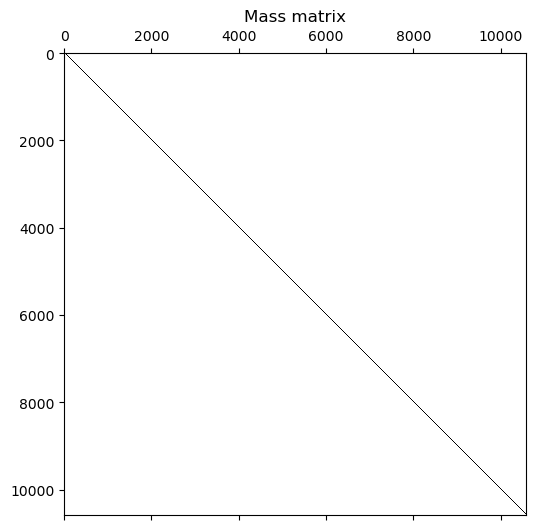

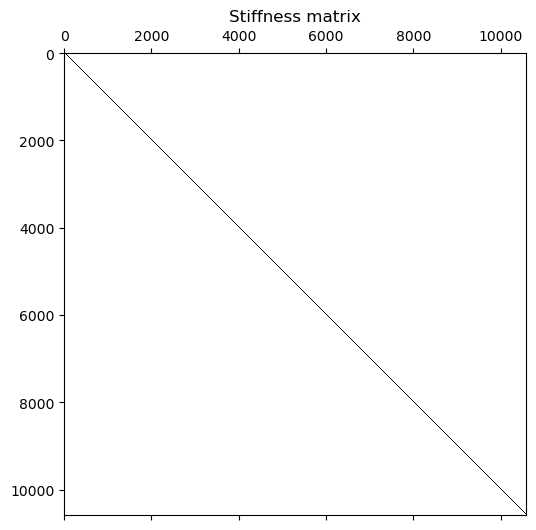

In [12]:
# Look at the matrix structure
plt.figure()
plt.spy(M)
plt.title("Mass matrix")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix")
pass

Text(0.5, 1.0, 'Stiffness matrix with linespring mooring')

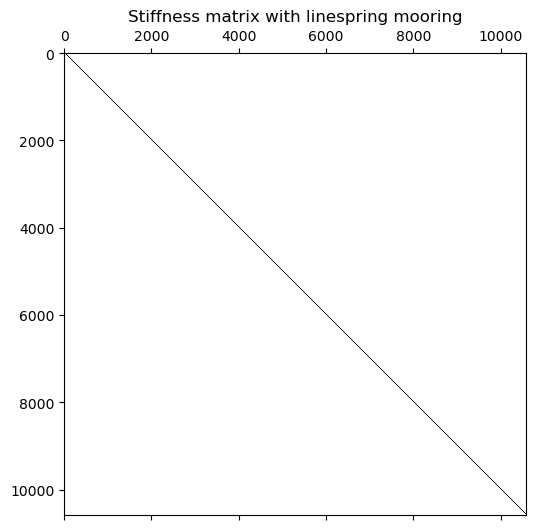

In [13]:
# --------------------------------------------------
# Mooring stiffness from horizontal and vertical tangent stiffness
# --------------------------------------------------

def AddMooringSpringHV(K, node_id, kh, kv, LDOF=6):
    """
    Adds horizontal and vertical mooring tangent stiffness
    to one 3D beam node.

    DOF order per node:
    [ux, uy, uz, rx, ry, rz]

    kh = horizontal transverse stiffness [N/m]
    kv = vertical stiffness [N/m]
    """

    i = int(node_id) * LDOF

    K[i + 1, i + 1] += kh   # y-direction, horizontal transverse
    K[i + 2, i + 2] += kv   # z-direction, vertical

    return K




cat_i = 0

for i, node in enumerate(mooring_nodes_tube1):

    node_1 = node
    node_2 = node + nodeDiff # node on the other tube
    s_moor = s[node]

    if s_moor < 1000:
        kh = 120e3
        kv = 46e3

    elif s_moor < 10000:
        kh = k_h[cat_i] * 1e3 / 2
        kv = k_v[cat_i] * 1e3 / 2
        cat_i += 1

    else:
        kh = 1200e3
        kv = 85e3

    K = AddMooringSpringHV(K, node_1, kh, kv, LDOF=LDOF)
    K = AddMooringSpringHV(K, node_2, kh, kv, LDOF=LDOF)

plt.figure()
plt.spy(K)
plt.title("Stiffness matrix with linespring mooring")





## Boundary conditions

To apply the boundary conditions, we will remove the rows associated to the fixed DOFs and add the contribution to the right-hand-side. First, we obtain the free and fixed DOFs.

[    0     1     2  5286  5287  5288  5292  5293  5294 10578 10579 10580]
[    3     4     5 ... 10581 10582 10583]
K shape: (10584, 10584)
K_FF shape: (10572, 10572)
Number of prescribed DOFs: 12
Number of free DOFs: 10572


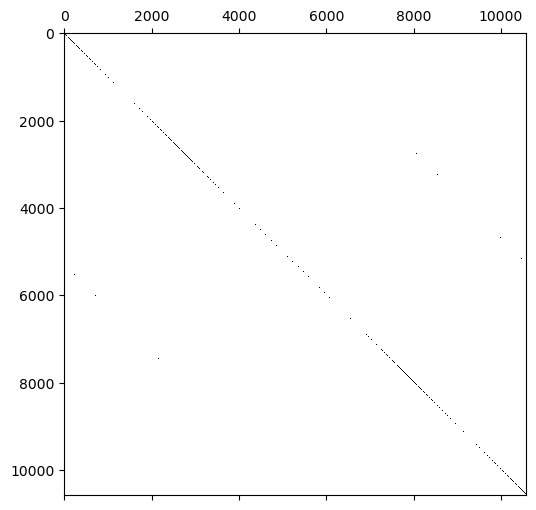

In [14]:
NodesClamp = (0, int(round(nNodes/2-1)), int(round(nNodes/2)), nNodes-1)

# Prescribed dofs
# Fixed Supports: ux=uy=uz=0 and rx=ry=rz=0 
# DofsP = np.empty([0], dtype=int)
# for n0 in NodesClamp:
#     DofsP = np.append(DofsP, n0*LDOF + np.arange(0,LDOF))

# Simple Supports: ux=uy=uz=0 and rx=ry=rz=Free 
DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(
        DofsP,
        n0*LDOF + np.array([0,1,2])
    )
# Free dofs
DofsF = np.arange(0, nDof)       # free DOFs
DofsF = np.delete(DofsF, DofsP)  # remove the fixed DOFs from the free DOFs array

print(DofsP)
print(DofsF)

# M_FF = [ M[iRow,DofsF].tolist() for iRow in DofsF ]
# K_FF = [ K[iRow,DofsF].tolist() for iRow in DofsF ]
# Q_FF = [ Q[iRow,DofsF].tolist() for iRow in DofsF ]

M_FF = M[np.ix_(DofsF, DofsF)]
K_FF = K[np.ix_(DofsF, DofsF)]
Q_FF = Q[np.ix_(DofsF, DofsF)]

# plt.figure()
# plt.spy(M_FF)
# plt.title("Mass matrix")
# plt.figure()
plt.spy(K_FF)
# plt.title("Stiffness matrix")
print("K shape:", K.shape)
print("K_FF shape:", K_FF.shape)
print("Number of prescribed DOFs:", len(DofsP))
print("Number of free DOFs:", len(DofsF))
pass

## Modal analysis

Using the matrices associated to the free DOFs, we can perform a modal analysis to get more information on how the structure will deform and determine the natural frequencies.

$$ ( K_{FF} - \omega^2 M_{FF} ) \phi = 0 $$

To compute the natural frequencies and mode shapes we use the `eig` command, which is part of the NumPy package. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

In [15]:
# mat = np.dot(np.linalg.inv(M_FF), K_FF)
# w2, vr = np.linalg.eig(mat)
# w = np.sqrt(w2.real)
# f = w/2/np.pi
# print(len(f))




In [16]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh

n_modes = 20

K_sp = csr_matrix(K_FF)
M_sp = csr_matrix(M_FF)

w2, vr = eigsh(K_sp, k=n_modes, M=M_sp, sigma=0.0, which="LM")

w = np.sqrt(np.maximum(w2, 0))
f = w/(2*np.pi)

idx = np.argsort(f)
f = f[idx]
vr = vr[:, idx]

print(f)

[0.00030698 0.00052936 0.00081361 0.00112782 0.0014564  0.00179307
 0.00213506 0.00248108 0.00283049 0.00318297 0.00353835 0.0038966
 0.0042577  0.0046217  0.00498864 0.00535855 0.00560593 0.00573149
 0.00579797 0.00610748]


In [17]:
idx = f.argsort()
f = f[idx]
vr = vr[:,idx]

print(f)
print("First 10 Natural frequencies (Hz) for", nNodes, "nodes:")
# print(f[854])

[0.00030698 0.00052936 0.00081361 0.00112782 0.0014564  0.00179307
 0.00213506 0.00248108 0.00283049 0.00318297 0.00353835 0.0038966
 0.0042577  0.0046217  0.00498864 0.00535855 0.00560593 0.00573149
 0.00579797 0.00610748]
First 10 Natural frequencies (Hz) for 1764 nodes:


In [18]:
nMode = len(f)
print(nMode)
ModalShape = np.zeros((nDof, nMode))
ModalShape[DofsF,:] = vr
print(vr.shape)

20
(10572, 20)


In [19]:
# # Plotting mode shapes
# plt.figure()
# cmap = plt.colormaps.get_cmap('Accent')
# cmap = cmap.colors
# nCmap = len(cmap)

# nCol = 2
# nRow = int(np.floor(nMode/nCol))+1

# vMode1 = 1
# vMode2 = 8

# def plotEle(DisplacedNode):
#     for iElem in np.arange(0, nEle-1):
#         NodeLeft = int(round(Ele[iElem][0]))
#         NodeRight = int(round(Ele[iElem][1]))
#         if(iElem == 0):
#             plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
#                      [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap], 
#                      label = "Mode "+str(iMode)+": f = "+str(np.round(f[iMode],6))+" Hz")
#         else:
#             plt.plot([DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]], 
#                      [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]], color=cmap[iMode%nCmap])


# # XY Plot
# for iMode in np.arange(vMode1, vMode2):    
#     Shape = ModalShape[:, iMode]

#     # Scale the mode such that maximum deformation is 10
#     MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
#     MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
#     MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
#     Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
#     Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
#     Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100    

#     # Get the deformed shape
#     DisplacedNode = ([i[0] + (iMode%3-1)*4000 for i in NodeC] + Shape[0::LDOF], 
#                      [i[1] + 300*np.floor(iMode/3) for i in NodeC] + Shape[1::LDOF])
    
#     plotEle(DisplacedNode)
#     plt.title("XY Plot")        
#     plt.grid('on')
#     plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3),
#           ncol=4, fancybox=True, shadow=True)    


# # XZ Plot
# plt.figure()
# for iMode in np.arange(vMode1, vMode2):    
#     Shape = ModalShape[:, iMode]

#     # Scale the mode such that maximum deformation is 10
#     MaxTranslationx = np.max(np.abs(Shape[0::LDOF]))
#     MaxTranslationy = np.max(np.abs(Shape[1::LDOF]))
#     MaxTranslationz = np.max(np.abs(Shape[2::LDOF]))
#     Shape[0::LDOF] = Shape[0::LDOF]/MaxTranslationx*100
#     Shape[1::LDOF] = Shape[1::LDOF]/MaxTranslationy*100
#     Shape[2::LDOF] = Shape[2::LDOF]/MaxTranslationz*100

#     # Get the deformed shape
#     DisplacedNode = ([i[0] + (iMode%3-1)*4000 for i in NodeC] + Shape[0::LDOF],
#                      [i[2] + np.floor(iMode/3)*300 for i in NodeC] + Shape[2::LDOF])
    
#     plotEle(DisplacedNode)
#     plt.title("XZ Plot")    
#     plt.grid('on')
#     plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3),
#           ncol=4, fancybox=True, shadow=True)    
    


# pass

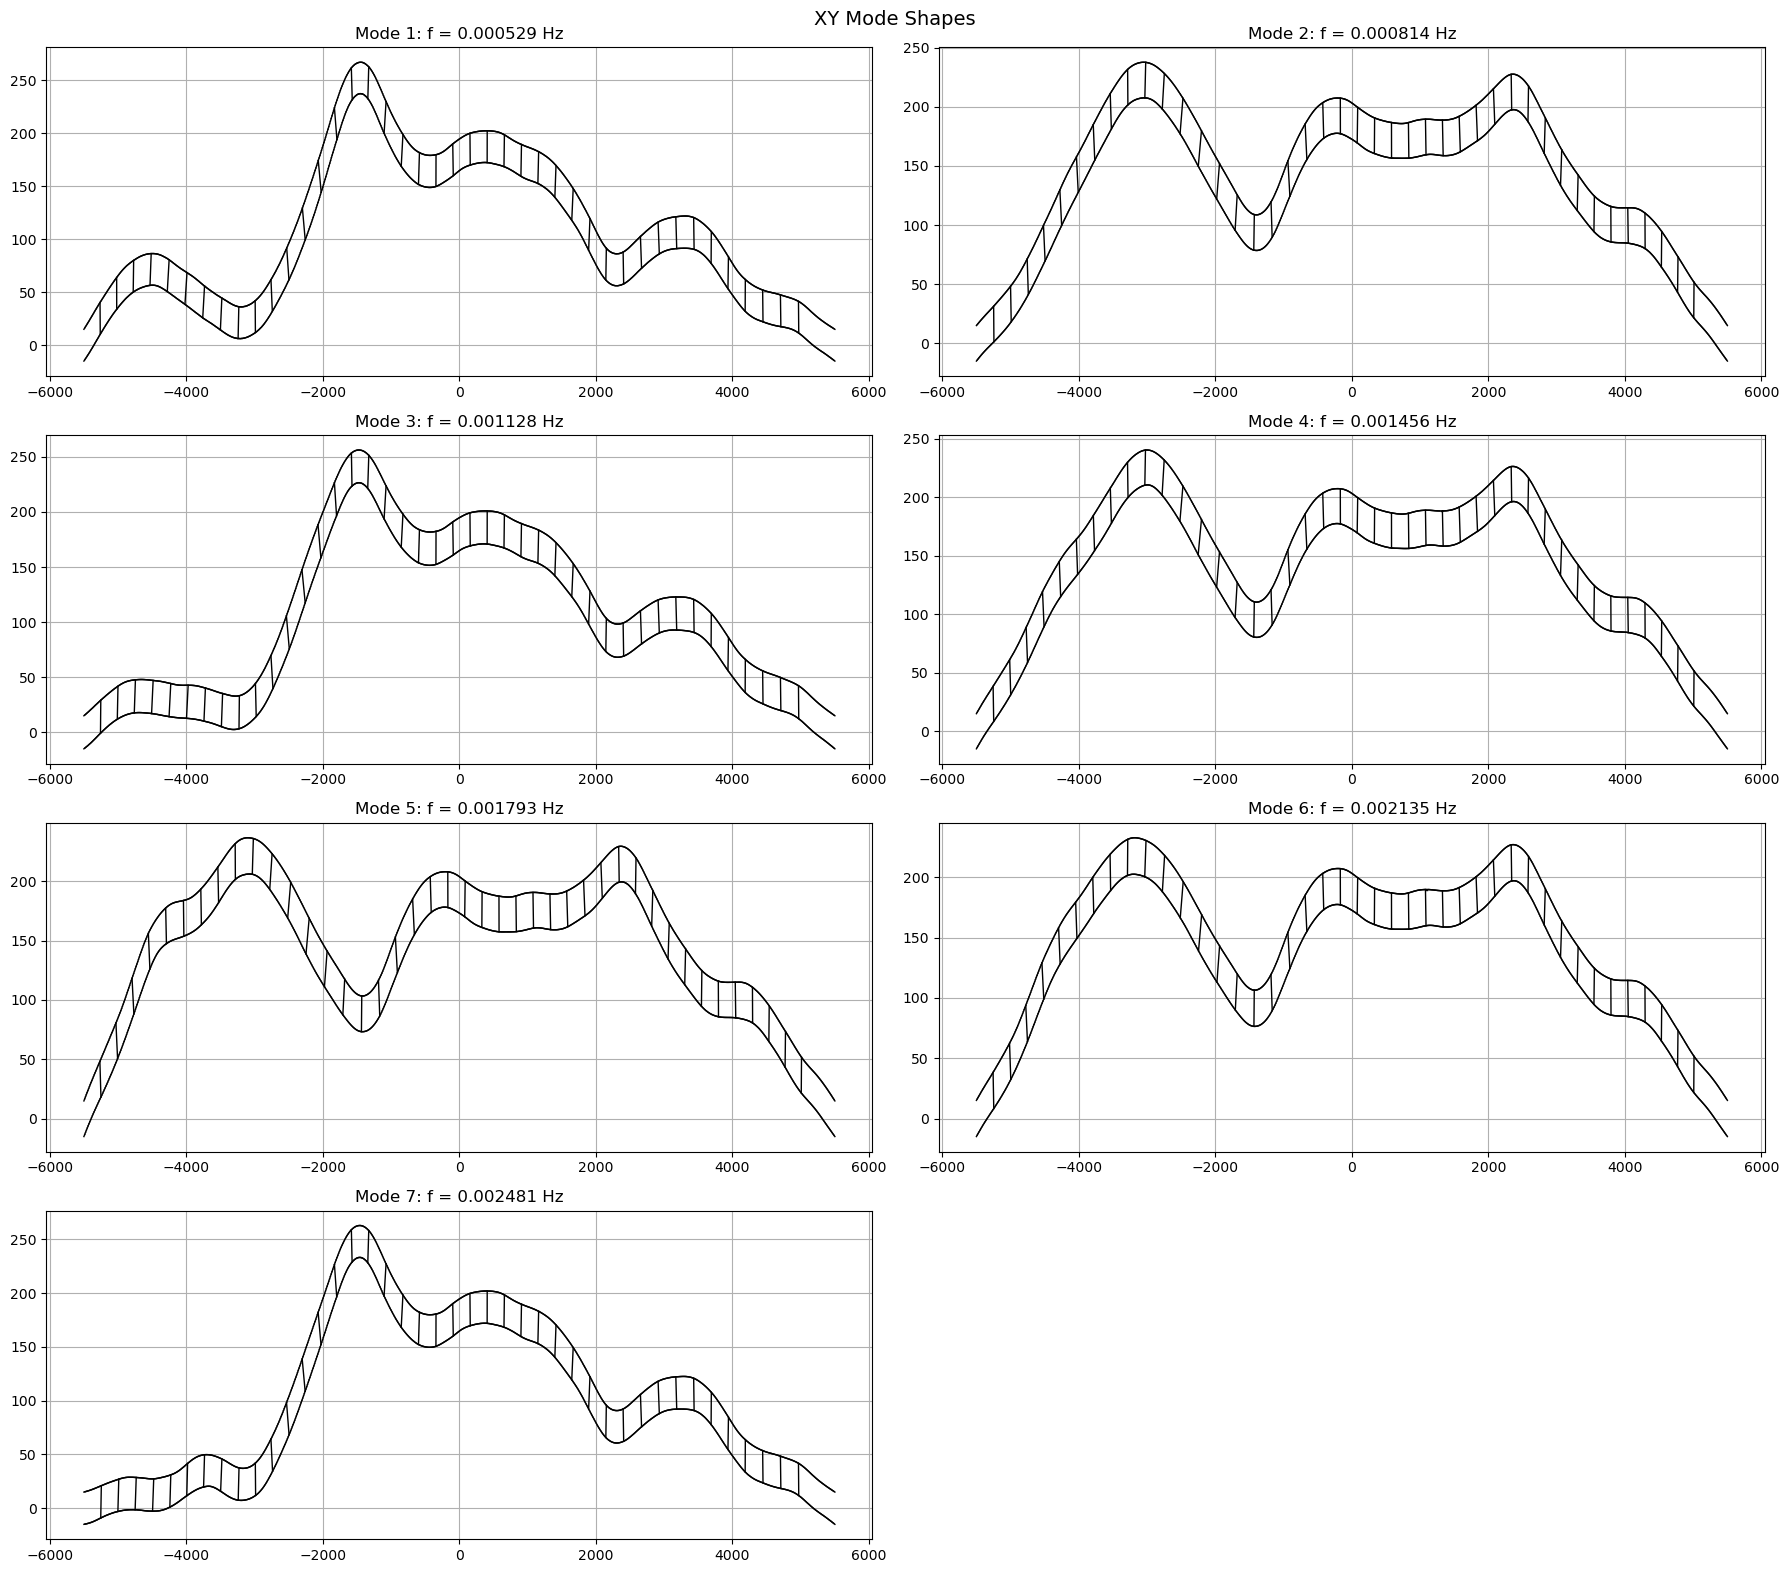

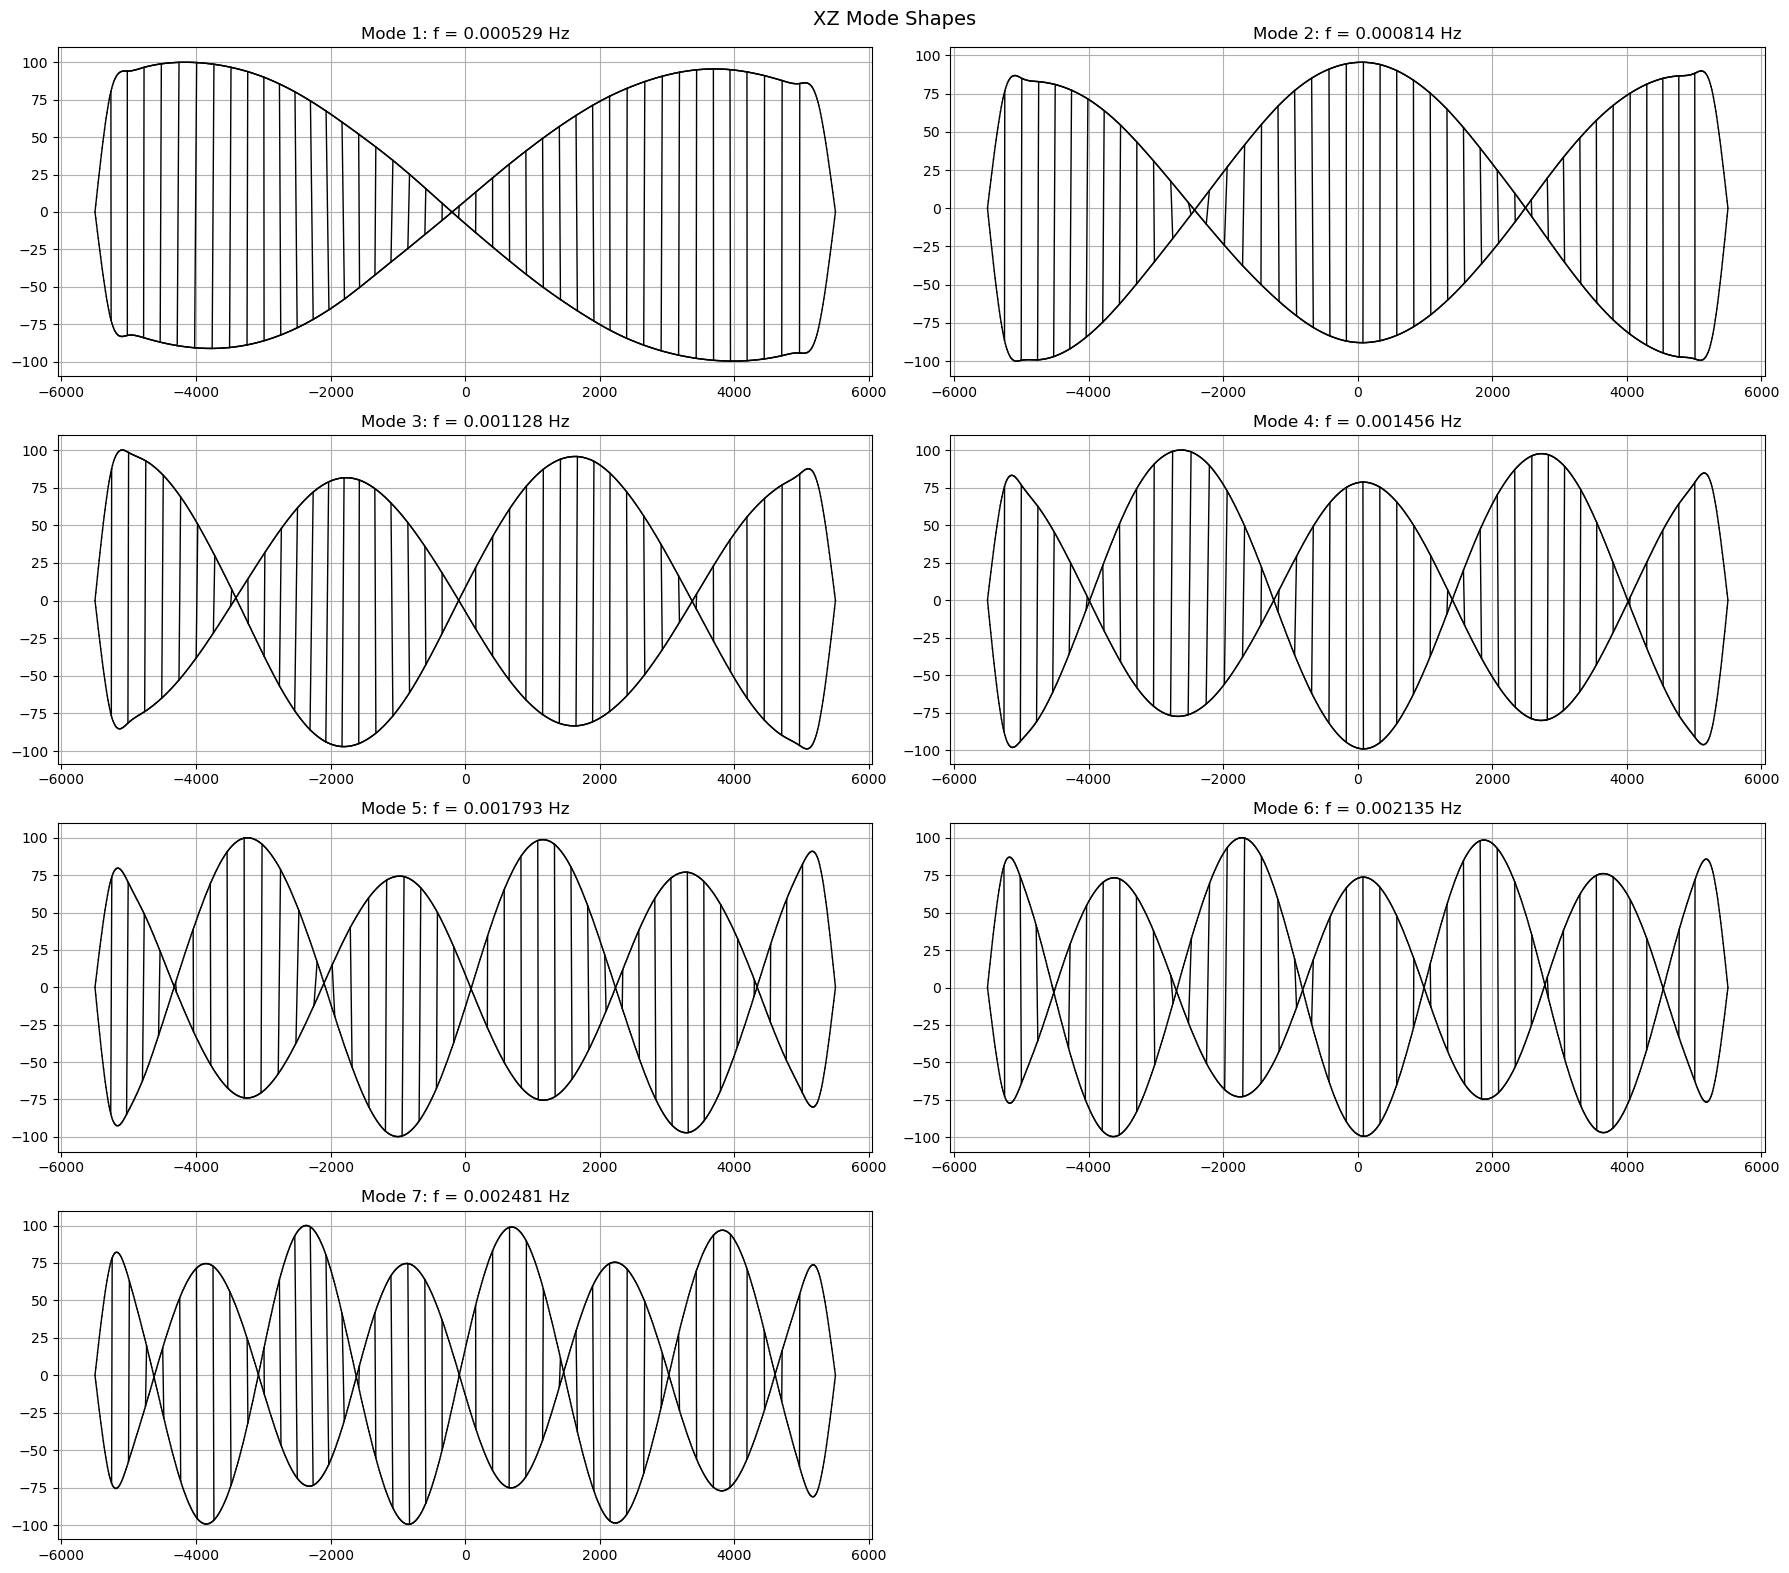

In [35]:
vMode1 = 1
vMode2 = 8
modes = np.arange(vMode1, vMode2)

nCol = 2
nRow = int(np.ceil(len(modes) / nCol))

scale = 100

def get_scaled_shape(iMode):
    Shape = ModalShape[:, iMode].copy()

    max_x = np.max(np.abs(Shape[0::LDOF]))
    max_y = np.max(np.abs(Shape[1::LDOF]))
    max_z = np.max(np.abs(Shape[2::LDOF]))

    if max_x > 0:
        Shape[0::LDOF] = Shape[0::LDOF] / max_x * scale
    if max_y > 0:
        Shape[1::LDOF] = Shape[1::LDOF] / max_y * scale
    if max_z > 0:
        Shape[2::LDOF] = Shape[2::LDOF] / max_z * scale

    return Shape


def plotEle_subplot(ax, DisplacedNode, iMode):
    for iElem in range(nEle - 1):
        NodeLeft = int(round(Ele[iElem][0]))
        NodeRight = int(round(Ele[iElem][1]))

        ax.plot(
            [DisplacedNode[0][NodeLeft], DisplacedNode[0][NodeRight]],
            [DisplacedNode[1][NodeLeft], DisplacedNode[1][NodeRight]],
            color='k',
            lw=1
        )

    ax.set_title(f"Mode {iMode}: f = {f[iMode]:.6f} Hz")
    ax.grid(True)
    # ax.axis("equal")


# XY subplots
fig, axs = plt.subplots(nRow, nCol, figsize=(18, 4*nRow))
axs = np.array(axs).reshape(-1)

for ax, iMode in zip(axs, modes):
    Shape = get_scaled_shape(iMode)

    DisplacedNode = (
        np.array([i[0] for i in NodeC]) + Shape[0::LDOF],
        np.array([i[1] for i in NodeC]) + Shape[1::LDOF]
    )

    plotEle_subplot(ax, DisplacedNode, iMode)

for ax in axs[len(modes):]:
    ax.axis("off")

fig.suptitle("XY Mode Shapes", fontsize=14)
plt.tight_layout()
plt.show()


# XZ subplots
fig, axs = plt.subplots(nRow, nCol, figsize=(18, 4*nRow))
axs = np.array(axs).reshape(-1)

for ax, iMode in zip(axs, modes):
    Shape = get_scaled_shape(iMode)

    DisplacedNode = (
        np.array([i[0] for i in NodeC]) + Shape[0::LDOF],
        np.array([i[2] for i in NodeC]) + Shape[2::LDOF]
    )

    plotEle_subplot(ax, DisplacedNode, iMode)

for ax in axs[len(modes):]:
    ax.axis("off")

fig.suptitle("XZ Mode Shapes", fontsize=14)
plt.tight_layout()
plt.show()

In [36]:
# import numpy as np
# import matplotlib.pyplot as plt

# NodeArr = np.array(NodeC, dtype=float)

# # Modes to plot
# modes_to_plot = np.arange(1, 8)   # Mode 423 to 430

# # Mesh split
# nodeDiff = int(nNodes / 2)

# # Plot settings
# scale = 100         # deformation scale, pas aan naar 20, 50, 100 etc.
# ncols = 4
# nrows = int(np.ceil(len(modes_to_plot) / ncols))

# def mode_disp(iMode, pers="XY"):
#     """Extract translational mode-shape components."""
#     phi = ModalShape[:, iMode]

#     ux = phi[0::LDOF]
#     uy = phi[1::LDOF]
#     uz = phi[2::LDOF]

#     if pers == "XY":
#         amp = np.max(np.sqrt(ux**2 + uy**2))
#         ux = ux / amp
#         uy = uy / amp
#         if amp < 1e-12:
#             return ux*0, uy*0, uz*0
#     elif pers == "XZ":
#         amp = np.max(np.sqrt(ux**2 + uz**2))
#         ux = ux / amp
#         uz = uz / amp
#         if amp < 1e-12:
#             return ux*0, uy*0, uz*0
#     # Normalize total displacement
#     # amp = np.max(np.sqrt(ux**2 + uy**2 + uz**2))

#     # if amp < 1e-12:
#     #     return ux*0, uy*0, uz*0

#     return ux / amp, uy / amp, uz / amp


# def plot_mode_view(ax, iMode, view="XY"):
#     ux, uy, uz = mode_disp(iMode, pers=view)

#     Xd = NodeArr[:, 0] + scale * ux
#     Yd = NodeArr[:, 1] + scale * uy
#     Zd = NodeArr[:, 2] + scale * uz

#     # Choose plotting plane
#     if view == "XY":
#         a0, b0 = NodeArr[:, 0], NodeArr[:, 1]
#         ad, bd = Xd, Yd
#         ylabel = "y (m)"
#     elif view == "XZ":
#         a0, b0 = NodeArr[:, 0], NodeArr[:, 2]
#         ad, bd = Xd, Zd
#         ylabel = "z (m)"

#     # Undeformed tunnel tubes
#     ax.plot(a0[:nodeDiff], b0[:nodeDiff], "--", color="gray", lw=1, alpha=0.6)
#     ax.plot(a0[nodeDiff:], b0[nodeDiff:], "--", color="gray", lw=1, alpha=0.6)

#     # Deformed tunnel tubes
#     ax.plot(ad[:nodeDiff], bd[:nodeDiff], "o-", color="blue", ms=3, lw=1.5,
#             label="Tunnel 1")
#     ax.plot(ad[nodeDiff:], bd[nodeDiff:], "o-", color="red", ms=3, lw=1.5,
#             label="Tunnel 2")

#     # Connectors / escape-route elements
#     for iEle in range(nEle):
#         n1 = int(round(Ele[iEle][0]))
#         n2 = int(round(Ele[iEle][1]))

#         # Only plot cross connections between the two tubes
#         if abs(n2 - n1) == nodeDiff:
#             ax.plot(
#                 [ad[n1], ad[n2]],
#                 [bd[n1], bd[n2]],
#                 color="green",
#                 lw=1,
#                 marker="o",
#                 ms=2
#             )

#     ax.set_title(f"Mode {iMode}: f = {f[iMode]:.6f} Hz")
#     ax.set_xlabel("x (m)")
#     ax.set_ylabel(ylabel)
#     # ax.set_aspect('equal', adjustable='box')
#     ax.grid(True)


# # -----------------------------
# # XY top view
# # -----------------------------
# fig, axs = plt.subplots(nrows, ncols, figsize=(18, 4*nrows), sharex=False, sharey=False)
# axs = axs.flatten()

# for ax, iMode in zip(axs, modes_to_plot):
#     plot_mode_view(ax, iMode, view="XY")

# for ax in axs[len(modes_to_plot):]:
#     ax.axis("off")

# fig.suptitle("XY mode shapes, top view", fontsize=16)
# plt.tight_layout()
# plt.show()


# # -----------------------------
# # XZ side view
# # -----------------------------
# fig, axs = plt.subplots(nrows, ncols, figsize=(18, 4*nrows), sharex=False, sharey=False)
# axs = axs.flatten()

# for ax, iMode in zip(axs, modes_to_plot):
#     plot_mode_view(ax, iMode, view="XZ")

# for ax in axs[len(modes_to_plot):]:
#     ax.axis("off")

# fig.suptitle("XZ mode shapes, side view", fontsize=16)
# plt.tight_layout()
# plt.show()


# Displacements Due to Forcing

In [37]:
# ============================================================
# 1. Wave, Morison and time settings
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Make sure node coordinates are available as a NumPy array
NodeArr = np.array(NodeC, dtype=float)

# Full number of DOFs
n_dof = nDof

# Wave and Morison parameters
Tp = 6.75          # peak / regular wave period [s]
H_wave = 2.4       # wave height [m]
h = 200.0          # water depth [m]
D = 12.7           # tunnel outer diameter [m]
Cd = 0.7           # drag coefficient [-]
Cm_morison = 1.0   # inertia coefficient [-]
rho_w = 1025.0     # water density [kg/m3]
g = 9.81

# Time discretisation
dt = Tp / 100
T_total = 5 * Tp
t = np.arange(0.0, T_total + dt, dt)
n_steps = len(t)

# Loaded nodes
loaded_nodes = np.arange(nNodes)

# Tributary length per node
# If segment_lengths already exists in your notebook, this uses it.
# Otherwise it estimates an average element length from Ele and NodeArr.
try:
    dx_node = np.mean(segment_lengths)
except NameError:
    elem_lengths = []
    for e in Ele:
        n1 = int(round(e[0]))
        n2 = int(round(e[1]))
        elem_lengths.append(np.linalg.norm(NodeArr[n2] - NodeArr[n1]))
    dx_node = np.mean(elem_lengths)

print("dt =", dt)
print("T_total =", T_total)
print("Number of time steps =", n_steps)
print("Mean tributary length per node =", dx_node)


def airy_wave_properties(T, h, g=9.81):
    omega = 2*np.pi/T

    def residual(k):
        return g*k*np.tanh(k*h) - omega**2

    k0 = omega**2/g
    k = fsolve(residual, k0)[0]

    L = 2*np.pi/k
    c = omega/k
    return omega, k, L, c


omega_wave, k_wave, L_wave, c_wave = airy_wave_properties(Tp, h, g)

print("Wave circular frequency omega =", omega_wave, "rad/s")
print("Wave number k =", k_wave, "1/m")
print("Wave length L =", L_wave, "m")
print("Wave celerity c =", c_wave, "m/s")


def airy_horizontal_velocity(z, x, tn, H, T, h, g=9.81):
    """
    Horizontal water particle velocity from Airy wave theory.
    z is measured relative to still water level, with seabed at z = -h.
    """
    a = H/2
    omega, k, _, _ = airy_wave_properties(T, h, g)

    return (
        a * omega
        * np.cosh(k*(z + h)) / np.sinh(k*h)
        * np.cos(k*x - omega*tn)
    )


def airy_horizontal_acceleration(z, x, tn, H, T, h, g=9.81):
    """
    Horizontal water particle acceleration from Airy wave theory.
    z is measured relative to still water level, with seabed at z = -h.
    """
    a = H/2
    omega, k, _, _ = airy_wave_properties(T, h, g)

    return (
        a * omega**2
        * np.cosh(k*(z + h)) / np.sinh(k*h)
        * np.sin(k*x - omega*tn)
    )


def morison_force_per_length(z, x, tn, H, T, h, D, Cd, Cm, rho=1025.0, g=9.81):
    """
    Morison force per unit length in global x-direction.
    Returns qx [N/m].
    """
    u = airy_horizontal_velocity(z, x, tn, H, T, h, g)
    udot = airy_horizontal_acceleration(z, x, tn, H, T, h, g)

    drag = 0.5 * rho * Cd * D * abs(u) * u
    inertia = rho * Cm * (np.pi * D**2 / 4) * udot

    return drag + inertia

dt = 0.0675
T_total = 33.75
Number of time steps = 501
Mean tributary length per node = 12.498320591732114
Wave circular frequency omega = 0.9308422677303091 rad/s
Wave number k = 0.08832490595242663 1/m
Wave length L = 71.13718649826609 m
Wave celerity c = 10.53884244418757 m/s


In [38]:
# ============================================================
# 2. Global wave-force vector
# ============================================================

def wave_force_global(tn):
    """
    Returns a full global force vector at time tn.
    The wave force is applied in global x-direction:
        dof = node*LDOF + 0

    Output size: n_dof
    """
    F_wave = np.zeros(n_dof)

    for node in loaded_nodes:
        x_node = NodeArr[node, 0]
        z_node = NodeArr[node, 2]

        qx = morison_force_per_length(
            z=z_node,
            x=x_node,
            tn=tn,
            H=H_wave,
            T=Tp,
            h=h,
            D=D,
            Cd=Cd,
            Cm=Cm_morison,
            rho=rho_w,
            g=g
        )

        Fx_node = qx * dx_node
        dof_x = node * LDOF + 0
        F_wave[dof_x] += Fx_node

    return F_wave


# Quick force check
F_check = wave_force_global(t[0])

print("Global force vector size:", F_check.shape)
print("Free force vector size:", F_check[DofsF].shape)
print("Maximum absolute wave force at t=0:", np.max(np.abs(F_check)), "N")
print("Total x-force at t=0:", np.sum(F_check[0::LDOF]), "N")

Global force vector size: (10584,)
Free force vector size: (10572,)
Maximum absolute wave force at t=0: 1687354.1878894493 N
Total x-force at t=0: 121639.817497232 N


In [39]:
# ============================================================
# 3. Modal superposition + Newmark integration
# ============================================================

# Number of modes to use.
# Use at least enough modes to cover the wave frequency range.
n_modes_used = min(20, vr.shape[1])

# Modal matrix with free DOFs only
PHI = vr[:, :n_modes_used].copy()

# Optional: mass-normalise modes to make M_modal approximately identity.
# This makes modal damping cleaner and avoids scaling problems.
for i in range(n_modes_used):
    m_i = PHI[:, i].T @ M_FF @ PHI[:, i]
    PHI[:, i] = PHI[:, i] / np.sqrt(m_i)

# Modal matrices
M_modal = PHI.T @ M_FF @ PHI
K_modal = PHI.T @ K_FF @ PHI

# Natural circular frequencies in the selected modal basis
omega_modal = np.sqrt(np.maximum(np.diag(K_modal) / np.diag(M_modal), 0.0))
f_modal = omega_modal / (2*np.pi)

# Modal damping
zeta = 0.02
C_modal = np.diag(2 * zeta * omega_modal * np.diag(M_modal))

print("Using", n_modes_used, "modes")
print("Selected modal frequencies [Hz]:")
print(f_modal)

# Newmark parameters: average acceleration method
beta = 1/4
gamma = 1/2

# Initial modal conditions
eta = np.zeros(n_modes_used)
eta_dot = np.zeros(n_modes_used)

F0_F = wave_force_global(t[0])[DofsF]
F0_modal = PHI.T @ F0_F

eta_ddot = np.linalg.solve(
    M_modal,
    F0_modal - C_modal @ eta_dot - K_modal @ eta
)

# Storage
eta_hist = np.zeros((n_steps, n_modes_used))
eta_dot_hist = np.zeros((n_steps, n_modes_used))
eta_ddot_hist = np.zeros((n_steps, n_modes_used))

uF_hist = np.zeros((n_steps, len(DofsF)))

eta_hist[0, :] = eta
eta_dot_hist[0, :] = eta_dot
eta_ddot_hist[0, :] = eta_ddot
uF_hist[0, :] = PHI @ eta

# Effective modal stiffness, constant because this is linear dynamics
K_eff_modal = (
    K_modal
    + gamma/(beta*dt) * C_modal
    + 1/(beta*dt**2) * M_modal
)

# Time integration
for n in range(n_steps - 1):

    F_next_F = wave_force_global(t[n+1])[DofsF]
    F_next_modal = PHI.T @ F_next_F

    F_eff_modal = (
        F_next_modal
        + M_modal @ (
            1/(beta*dt**2) * eta
            + 1/(beta*dt) * eta_dot
            + (1/(2*beta) - 1) * eta_ddot
        )
        + C_modal @ (
            gamma/(beta*dt) * eta
            + (gamma/beta - 1) * eta_dot
            + dt*(gamma/(2*beta) - 1) * eta_ddot
        )
    )

    eta_new = np.linalg.solve(K_eff_modal, F_eff_modal)

    eta_ddot_new = (
        1/(beta*dt**2) * (eta_new - eta)
        - 1/(beta*dt) * eta_dot
        - (1/(2*beta) - 1) * eta_ddot
    )

    eta_dot_new = eta_dot + dt*((1 - gamma)*eta_ddot + gamma*eta_ddot_new)

    eta = eta_new
    eta_dot = eta_dot_new
    eta_ddot = eta_ddot_new

    eta_hist[n+1, :] = eta
    eta_dot_hist[n+1, :] = eta_dot
    eta_ddot_hist[n+1, :] = eta_ddot

    # Reconstruct free-DOF displacement
    uF_hist[n+1, :] = PHI @ eta

print("Finished modal-Newmark time integration.")
print("uF_hist shape =", uF_hist.shape)

Using 20 modes
Selected modal frequencies [Hz]:
[0.00030698 0.00052936 0.00081361 0.00112782 0.0014564  0.00179307
 0.00213506 0.00248108 0.00283049 0.00318297 0.00353835 0.0038966
 0.0042577  0.0046217  0.00498864 0.00535855 0.00560593 0.00573149
 0.00579797 0.00610748]
Finished modal-Newmark time integration.
uF_hist shape = (501, 10572)


In [40]:
# ============================================================
# 4. Convert free-DOF displacement history to full DOF history
# ============================================================

u_full_hist = np.zeros((n_steps, n_dof))
u_full_hist[:, DofsF] = uF_hist

# Nodal displacement histories
u_nodes_hist = u_full_hist.reshape((n_steps, nNodes, LDOF))

ux_hist = u_nodes_hist[:, :, 0]
uy_hist = u_nodes_hist[:, :, 1]
uz_hist = u_nodes_hist[:, :, 2]

print("Maximum |ux| =", np.max(np.abs(ux_hist)), "m")
print("Maximum |uy| =", np.max(np.abs(uy_hist)), "m")
print("Maximum |uz| =", np.max(np.abs(uz_hist)), "m")

Maximum |ux| = 9.528844585449682e-37 m
Maximum |uy| = 1.704155245627831e-35 m
Maximum |uz| = 1.002734210495786e-21 m


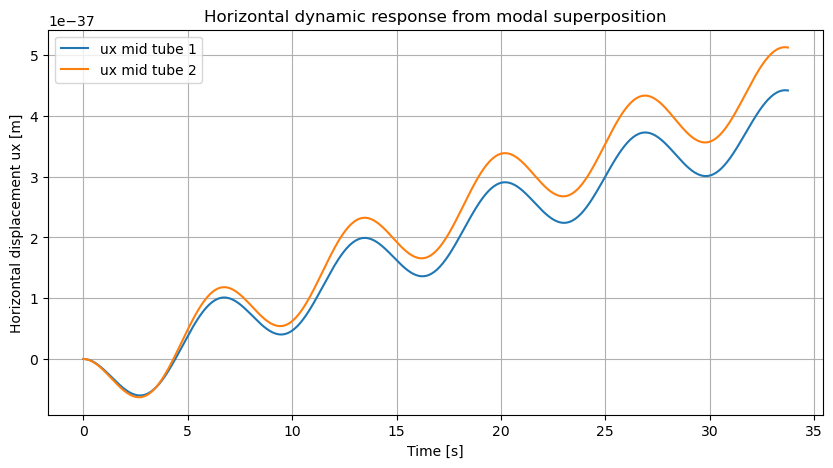

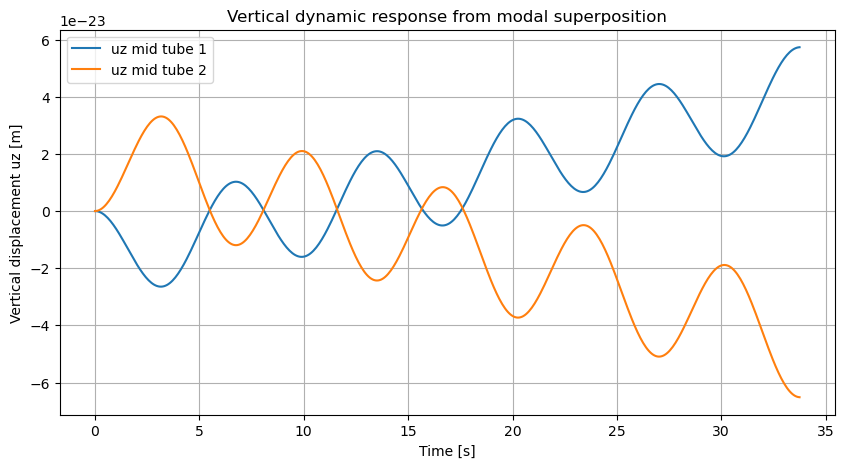

In [41]:
# ============================================================
# 5. Plot response at important nodes
# ============================================================

# Pick representative nodes
mid_tube1 = nodeDiff // 2
mid_tube2 = nodeDiff + nodeDiff // 2

nodes_to_plot = [mid_tube1, mid_tube2]
labels = ["mid tube 1", "mid tube 2"]

plt.figure(figsize=(10, 5))
for node, lab in zip(nodes_to_plot, labels):
    plt.plot(t, ux_hist[:, node], label=f"ux {lab}")

plt.xlabel("Time [s]")
plt.ylabel("Horizontal displacement ux [m]")
plt.title("Horizontal dynamic response from modal superposition")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(10, 5))
for node, lab in zip(nodes_to_plot, labels):
    plt.plot(t, uz_hist[:, node], label=f"uz {lab}")

plt.xlabel("Time [s]")
plt.ylabel("Vertical displacement uz [m]")
plt.title("Vertical dynamic response from modal superposition")
plt.grid(True)
plt.legend()
plt.show()

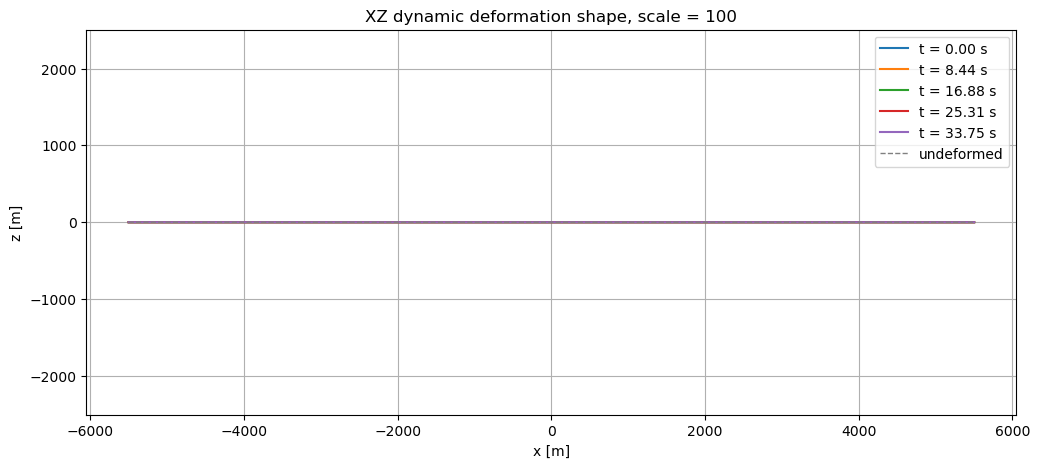

In [42]:
# ============================================================
# 6. Plot deformed tunnel shape at selected time instants
# ============================================================

times_to_plot = [0, int(0.25*n_steps), int(0.50*n_steps), int(0.75*n_steps), n_steps-1]
scale = 100

plt.figure(figsize=(12, 5))

for it in times_to_plot:
    x_def = NodeArr[:, 0] + scale * ux_hist[it, :]
    z_def = NodeArr[:, 2] + scale * uz_hist[it, :]

    plt.plot(x_def, z_def, label=f"t = {t[it]:.2f} s")

plt.plot(NodeArr[:, 0], NodeArr[:, 2], "--", color="gray", lw=1, label="undeformed")

plt.xlabel("x [m]")
plt.ylabel("z [m]")
plt.title(f"XZ dynamic deformation shape, scale = {scale}")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()

In [ ]:
# F_static = F.copy()

# dt = 0.05
# T_total = 100
# t = np.arange(0, T_total + dt, dt)
# Tp = 6.75
# h = 200 

# def airy_wave_properties(T, h, g=9.81):

#     omega = 2*np.pi/T

#     def residual(k):
#         return g*k*np.tanh(k*h) - omega**2

#     k0 = omega**2/g
#     k = fsolve(residual, k0)[0]

#     L = 2*np.pi/k
#     c = omega/k

#     return omega, k, L, c

# n_steps = len(t)
# n_dof = len(F)
# omega, k, L, c = airy_wave_properties(Tp, h)

# def airy_horizontal_velocity(z, x, t, H, T, h, g=9.81):
#     """
#     Horizontal water particle velocity from Airy wave theory.

#     z = vertical coordinate [m], with still water level at z = 0
#         seabed is at z = -h
#     x = horizontal position [m]
#     """
#     a = H/2
#     omega, k, _, _ = airy_wave_properties(T, h, g)

#     return (
#         a * omega
#         * np.cosh(k*(z + h)) / np.sinh(k*h)
#         * np.cos(k*x - omega*t)
#     )


# def airy_horizontal_acceleration(z, x, t, H, T, h, g=9.81):
#     """
#     Horizontal water particle acceleration from Airy wave theory.
#     """
#     a = H/2
#     omega, k, _, _ = airy_wave_properties(T, h, g)

#     return (
#         a * omega**2
#         * np.cosh(k*(z + h)) / np.sinh(k*h)
#         * np.sin(k*x - omega*t)
#     )


# def morison_force_per_length(z, x, t, H, T, h, D, Cd, Cm, rho=1025, g=9.81):
#     """
#     Morison force per unit length in global x-direction.

#     Returns qx [N/m]
#     """
#     u = airy_horizontal_velocity(z, x, t, H, T, h, g)
#     udot = airy_horizontal_acceleration(z, x, t, H, T, h, g)

#     drag = 0.5 * rho * Cd * D * abs(u) * u
#     inertia = rho * Cm * (np.pi * D**2 / 4) * udot

#     qx = drag + inertia

#     return qx


# F_time = np.zeros((n_steps, n_dof))
# loaded_nodes = np.arange(nNodes)
# F_ext_F = F_time[nNodes+1, DofsF]

# alpha_R = 0.0
# beta_R = 0.0
# zeta = 0.02 
# C_FF = alpha_R*M_FF + beta_R*K_FF
# H_wave = 2.4 

# beta = 1/4
# gamma = 1/2

# D = 12.7
# Cd = 0.7

# dynamic_terms = (
#     1/(beta*dt**2)*M_FF
#     + gamma/(beta*dt)*C_FF
# )

# for n, tn in enumerate(t):

#     for node in loaded_nodes:

#         x = NodeArr[node, 0]
#         z = NodeArr[node, 2]

#         qx = morison_force_per_length(
#             z=z,
#             x=x,
#             t=tn,
#             H=H_wave,
#             T=Tp,
#             h=h,
#             D=D,
#             Cd=Cd,
#             Cm=Cm
#         )

#         Fx_node = qx * np.mean(segment_lengths)

#         dof_x = node*LDOF + 0

#         F_time[n, dof_x] += Fx_node




NameError: name 'F' is not defined

In [ ]:
# def wave_force_global(tn):
#     """
#     Returns full global force vector F_wave at time tn.
#     Wave force is applied in global x-direction using Morison force.
#     """

#     F_wave = np.zeros(n_dof)

#     for node in loaded_nodes:

#         x = NodeArr[node, 0]
#         z = NodeArr[node, 2]

#         qx = morison_force_per_length(
#             z=z,
#             x=x,
#             t=tn,
#             H=H_wave,
#             T=Tp,
#             h=h,
#             D=D,
#             Cd=Cd,
#             Cm=Cm
#         )

#         Fx_node = qx * np.mean(segment_lengths)

#         dof_x = node * LDOF + 0
#         F_wave[dof_x] += Fx_node

#     return F_wave

In [ ]:
# # ==============================
# # Modal superposition + Newmark
# # ==============================

# # Number of modes to use
# n_modes_used = 20

# # Modal matrix: free DOFs only
# PHI = vr[:, :n_modes_used].copy()

# # Modal mass/stiffness
# M_modal = PHI.T @ M_FF @ PHI
# K_modal = PHI.T @ K_FF @ PHI

# # Natural circular frequencies
# omega_modal = np.sqrt(np.diag(K_modal) / np.diag(M_modal))

# # Modal damping
# zeta = 0.02
# C_modal = np.diag(2 * zeta * omega_modal * np.diag(M_modal))

# # Time settings
# Tp = 6.75
# T_total = 5 * Tp
# dt = Tp / 100
# t = np.arange(0, T_total + dt, dt)
# n_steps = len(t)

# # Modal initial conditions
# eta = np.zeros(n_modes_used)
# eta_dot = np.zeros(n_modes_used)

# # Initial modal force
# F0 = wave_force_global(t[0])[DofsF]
# F0_modal = PHI.T @ F0

# eta_ddot = np.linalg.solve(
#     M_modal,
#     F0_modal - C_modal @ eta_dot - K_modal @ eta
# )

# # Newmark parameters
# beta = 1/4
# gamma = 1/2

# # Storage
# eta_hist = np.zeros((n_steps, n_modes_used))
# u_hist = np.zeros((n_steps, len(DofsF)))

# eta_hist[0, :] = eta
# u_hist[0, :] = PHI @ eta

# # Effective modal stiffness
# K_eff = (
#     K_modal
#     + gamma / (beta * dt) * C_modal
#     + 1 / (beta * dt**2) * M_modal
# )

# # Time integration
# for n in range(n_steps - 1):

#     F_next = wave_force_global(t[n+1])[DofsF]
#     F_next_modal = PHI.T @ F_next

#     F_eff = (
#         F_next_modal
#         + M_modal @ (
#             1/(beta*dt**2) * eta
#             + 1/(beta*dt) * eta_dot
#             + (1/(2*beta) - 1) * eta_ddot
#         )
#         + C_modal @ (
#             gamma/(beta*dt) * eta
#             + (gamma/beta - 1) * eta_dot
#             + dt*(gamma/(2*beta) - 1) * eta_ddot
#         )
#     )

#     eta_new = np.linalg.solve(K_eff, F_eff)

#     eta_ddot_new = (
#         1/(beta*dt**2) * (eta_new - eta)
#         - 1/(beta*dt) * eta_dot
#         - (1/(2*beta) - 1) * eta_ddot
#     )

#     eta_dot_new = (
#         eta_dot
#         + dt * ((1 - gamma) * eta_ddot + gamma * eta_ddot_new)
#     )

#     eta = eta_new
#     eta_dot = eta_dot_new
#     eta_ddot = eta_ddot_new

#     eta_hist[n+1, :] = eta
#     u_hist[n+1, :] = PHI @ eta


# # ==============================
# # Plot midpoint displacement
# # ==============================

# mid_node = nNodes // 2

# dof_x_mid = mid_node * LDOF + 0
# dof_y_mid = mid_node * LDOF + 1
# dof_z_mid = mid_node * LDOF + 2

# idx_x = np.where(DofsF == dof_x_mid)[0]
# idx_y = np.where(DofsF == dof_y_mid)[0]
# idx_z = np.where(DofsF == dof_z_mid)[0]

# plt.figure(figsize=(10, 5))

# if len(idx_x) > 0:
#     plt.plot(t, u_hist[:, idx_x[0]], label="ux midpoint")

# if len(idx_y) > 0:
#     plt.plot(t, u_hist[:, idx_y[0]], label="uy midpoint")

# if len(idx_z) > 0:
#     plt.plot(t, u_hist[:, idx_z[0]], label="uz midpoint")

# plt.xlabel("Time [s]")
# plt.ylabel("Displacement [m]")
# plt.title("Midpoint dynamic displacement using modal superposition")
# plt.grid(True)
# plt.legend()
# plt.show()

NameError: name 'wave_force_global' is not defined

## Solving K * u = F

In [ ]:

# fixed_nodes = [0]

# fixed_dofs = []

# for node in fixed_nodes:
#     fixed_dofs += [
#         node*LDOF + 0,  # ux
#         node*LDOF + 1,  # uy
#         node*LDOF + 2,  # uz
#         node*LDOF + 3,  # rx
#         node*LDOF + 4,  # ry
#         node*LDOF + 5   # rz
#     ]

# fixed_dofs = np.array(fixed_dofs)

In [ ]:
# ndof = K.shape[0]
# F = np.zeros(ndof)

# len_tunnel = 11000  # m
# n_nodes = nNodes

# total_hor_force_per_node = (570e3 / 50) * len_tunnel / n_nodes
# total_ver_force_per_node = (414/50 + 250)* len_tunnel * 1e3 / n_nodes

# for node in range(n_nodes):
#     F[node*LDOF + 2] = -total_ver_force_per_node 
#     F[node*LDOF + 0] =  total_hor_force_per_node    

# n_nodes_per_tube = nodeDiff  # or len(TunCX_tube1)

# fixed_nodes = [
#     0,                          # tube 1 start
#     n_nodes_per_tube - 1,        # tube 1 end
#     n_nodes_per_tube,            # tube 2 start
#     2*n_nodes_per_tube - 1       # tube 2 end
# ]

# fixed_dofs = []
# for node in fixed_nodes:
#     fixed_dofs += list(range(node*LDOF, node*LDOF + LDOF))

# fixed_dofs = np.array(fixed_dofs)

# free_dofs = DofsF

# K_reduced = K[np.ix_(free_dofs, free_dofs)]
# F_reduced = F[DofsF]

# u_reduced = np.linalg.solve(K_FF, F_reduced)

# u_full = np.zeros(nDof)
# u_full[DofsF] = u_reduced

# ux = u_full[0::6]
# uy = u_full[1::6]
# uz = u_full[2::6]

# max_uz = np.max(uz)
# min_uz = np.min(uz)
# max_ux = np.max(np.abs(ux))
# max_uy = np.max(np.abs(uy))
# print("max uz =", max_uz)
# print("min uz =", min_uz)
# print("max ux =", max_ux)
# print("max uy =", np.max(np.abs(uy)))


max uz = 0.0
min uz = -27.26670399298417
max ux = 0.1215097085756933
max uy = 0.03565404322334776


In [ ]:
# Kz_total = np.sum(K[2::6, 2::6])
# Fz_total = abs(np.sum(F[2::6]))

# uz_est = Fz_total / Kz_total

# print("Total vertical force [N] =", Fz_total, "Total vertical stiffness [N/m] =", Kz_total)
# print("Approx total vertical stiffness [N/m] =", Kz_total)
# print("Rough vertical displacement [m] =", uz_est)

Total vertical force [N] = 2841080000.0 Total vertical stiffness [N/m] = 162107500.00016618
Approx total vertical stiffness [N/m] = 162107500.00016618
Rough vertical displacement [m] = 17.52590102245169


In [ ]:
# kv_total = 0

# for i, node in enumerate(mooring_nodes_tube1):
#     node_1 = node
#     node_2 = node + nodeDiff # node on the other tube

#     kv_total += K[node_1*LDOF + 2, node_1*LDOF + 2]
#     kv_total += K[node_2*LDOF + 2, node_2*LDOF + 2]

# print("Total mooring vertical stiffness [N/m] =", kv_total)
# print("Expected rigid vertical displacement [m] =", Fz_total / kv_total)

Total mooring vertical stiffness [N/m] = 1523993791054605.0
Expected rigid vertical displacement [m] = 1.8642333168785223e-06


In [ ]:
# results = []

# results.append({
#     "Le": Le,
#     "nNode": nNodes,
#     "max_uz": max_uz,
#     "max_ux": max_ux,
#     "max_uy": max_uy,
#     "min_uz": min_uz,
#     "first_freqs": f[:10]
# })

# FEM non-linear with dynamic forcing, damping and time integration

### Adding time steps

### Adding Non-linearity to mooring stiffness

In [ ]:
# def mooring_force_and_tangent(d, k0, k2):
#     F = k0*d + k2*d**3
#     kt = k0 + 3*k2*d**2
#     return F, kt

### Adding force per element instead of nodes

In [ ]:
# F_static = F.copy()

# dt = 0.05
# T_total = 100
# t = np.arange(0, T_total + dt, dt)
# Tp = 6.75
# h = 200 

# def airy_wave_properties(T, h, g=9.81):

#     omega = 2*np.pi/T

#     def residual(k):
#         return g*k*np.tanh(k*h) - omega**2

#     k0 = omega**2/g
#     k = fsolve(residual, k0)[0]

#     L = 2*np.pi/k
#     c = omega/k

#     return omega, k, L, c

# n_steps = len(t)
# n_dof = len(F)
# omega, k, L, c = airy_wave_properties(Tp, h)

# def airy_horizontal_velocity(z, x, t, H, T, h, g=9.81):
#     """
#     Horizontal water particle velocity from Airy wave theory.

#     z = vertical coordinate [m], with still water level at z = 0
#         seabed is at z = -h
#     x = horizontal position [m]
#     """
#     a = H/2
#     omega, k, _, _ = airy_wave_properties(T, h, g)

#     return (
#         a * omega
#         * np.cosh(k*(z + h)) / np.sinh(k*h)
#         * np.cos(k*x - omega*t)
#     )


# def airy_horizontal_acceleration(z, x, t, H, T, h, g=9.81):
#     """
#     Horizontal water particle acceleration from Airy wave theory.
#     """
#     a = H/2
#     omega, k, _, _ = airy_wave_properties(T, h, g)

#     return (
#         a * omega**2
#         * np.cosh(k*(z + h)) / np.sinh(k*h)
#         * np.sin(k*x - omega*t)
#     )


# def morison_force_per_length(z, x, t, H, T, h, D, Cd, Cm, rho=1025, g=9.81):
#     """
#     Morison force per unit length in global x-direction.

#     Returns qx [N/m]
#     """
#     u = airy_horizontal_velocity(z, x, t, H, T, h, g)
#     udot = airy_horizontal_acceleration(z, x, t, H, T, h, g)

#     drag = 0.5 * rho * Cd * D * abs(u) * u
#     inertia = rho * Cm * (np.pi * D**2 / 4) * udot

#     qx = drag + inertia

#     return qx


# F_time = np.zeros((n_steps, n_dof))
# loaded_nodes = np.arange(nNodes)
# F_ext_F = F_time[nNodes+1, DofsF]

# alpha_R = 0.0
# beta_R = 0.0
# zeta = 0.02 
# C_FF = alpha_R*M_FF + beta_R*K_FF
# H_wave = 2.4 

# beta = 1/4
# gamma = 1/2

# D = 12.7
# Cd = 0.7

# dynamic_terms = (
#     1/(beta*dt**2)*M_FF
#     + gamma/(beta*dt)*C_FF
# )

# for n, tn in enumerate(t):

#     for node in loaded_nodes:

#         x = NodeArr[node, 0]
#         z = NodeArr[node, 2]

#         qx = morison_force_per_length(
#             z=z,
#             x=x,
#             t=tn,
#             H=H_wave,
#             T=Tp,
#             h=h,
#             D=D,
#             Cd=Cd,
#             Cm=Cm
#         )

#         Fx_node = qx * np.mean(segment_lengths)

#         dof_x = node*LDOF + 0

#         F_time[n, dof_x] += Fx_node




NameError: name 'F' is not defined

In [ ]:
# n_free = len(DofsF)
# F0 = F_time[0, DofsF]

# d=0
# u = np.zeros(len(DofsF))
# v = np.zeros(len(DofsF))
# a = np.linalg.solve(M_FF, F0 - C_FF @ v - K_FF @ u)

# u_trial = u.copy()
# v_trial = v.copy()
# a_trial = a.copy()

# mooring_nodes = np.concatenate((mooring_nodes_tube1, mooring_nodes_tube2))

# max_iter = 20
# tol = 1e-6

# k0 = kh
# k2 = 0.0


# u_eq_z = np.max(uz)
# u_eq_y = np.max(uy) 
# u_eq_x = np.max(ux) 

# mooring_force_and_tangent(d, k0, k2)

# for iteration in range(max_iter):

#     F_moor = np.zeros(n_free)
#     K_moor = np.zeros((n_free, n_free))

#     for node in mooring_nodes:
#         dof = node*LDOF + 2   # vertical z DOF in full system

#         if dof in DofsF:
#             j = np.where(DofsF == dof)[0][0]

#             d = u_trial[j] - u_eq_z

#             Fnl, kt = mooring_force_and_tangent(d, k0, k2)

#             F_moor[j] += Fnl
#             K_moor[j, j] += kt

#     R = F_ext_F - M_FF @ a_trial - C_FF @ v_trial - K_FF @ u_trial - F_moor

#     K_tangent = K_FF + K_moor + dynamic_terms

#     du = np.linalg.solve(K_tangent, R)

#     u_trial += du

#     if np.linalg.norm(du) < tol:
#         break

### Running it with time steps

In [ ]:
# dt = 0.05
# n_steps = 2 

# t = np.arange(0, n_steps*dt + dt, dt)

# F0 = F_time[0, DofsF]

# u = np.zeros(len(DofsF))
# v = np.zeros(len(DofsF))
# a = np.linalg.solve(M_FF, F0 - C_FF @ v - K_FF @ u)

# K_eff = K_FF + gamma/(beta*dt)*C_FF + 1/(beta*dt**2)*M_FF

# for n in range(n_steps):
#     F_next = F_time[n+1, DofsF]

#     F_eff = (
#         F_next
#         + M_FF @ (1/(beta*dt**2)*u + 1/(beta*dt)*v + (1/(2*beta)-1)*a)
#         + C_FF @ (gamma/(beta*dt)*u + (gamma/beta-1)*v + dt*(gamma/(2*beta)-1)*a)
#     )

#     u_new = np.linalg.solve(K_eff, F_eff)

#     a_new = 1/(beta*dt**2)*(u_new - u) - 1/(beta*dt)*v - (1/(2*beta)-1)*a
#     v_new = v + dt*((1-gamma)*a + gamma*a_new)

#     u, v, a = u_new, v_new, a_new


# print(u)
# print(len(u))
# print(v)
# print(len(v))

# u_full = np.zeros(n_dof)
# u_full[DofsF] = u

# u_nodes = u_full.reshape((nNodes, LDOF))

# ux = u_nodes[:, 0]
# uy = u_nodes[:, 1]
# uz = u_nodes[:, 2]

# rx = u_nodes[:, 3]
# ry = u_nodes[:, 4]
# rz = u_nodes[:, 5]

[ 0.00000000e+00  0.00000000e+00 -3.05940937e-07 ...  0.00000000e+00
  0.00000000e+00  3.28661962e-07]
10572
[ 0.00000000e+00  0.00000000e+00 -2.90793191e-06 ...  0.00000000e+00
  0.00000000e+00  4.20911291e-06]
10572


In [ ]:
# u_full = np.zeros(n_dof)
# u_full[DofsF] = u

# u_nodes = u_full.reshape((nNodes, LDOF))

# ux = u_nodes[:, 0]
# uy = u_nodes[:, 1]
# uz = u_nodes[:, 2]

# rx = u_nodes[:, 3]
# ry = u_nodes[:, 4]
# rz = u_nodes[:, 5]

# print("max ux =", np.max(np.abs(ux)))
# print("max uy =", np.max(np.abs(uy)))
# print("max uz =", np.max(np.abs(uz)))
# print("max rx =", np.max(np.abs(rx)))
# print("max ry =", np.max(np.abs(ry)))
# print("max rz =", np.max(np.abs(rz)))
# print("min uz =", np.min(uz))

max ux = 5.9471440334121474e-05
max uy = 4.653914071102779e-06
max uz = 0.0
max rx = 0.0
max ry = 0.0
max rz = 3.286619624397903e-07
min uz = 0.0


In [ ]:
# print(len(free_dofs))
# print(len(DofsF))

10572
10572


Text(0.5, 1.0, 'Deformed shape, scale = 1000000000000')

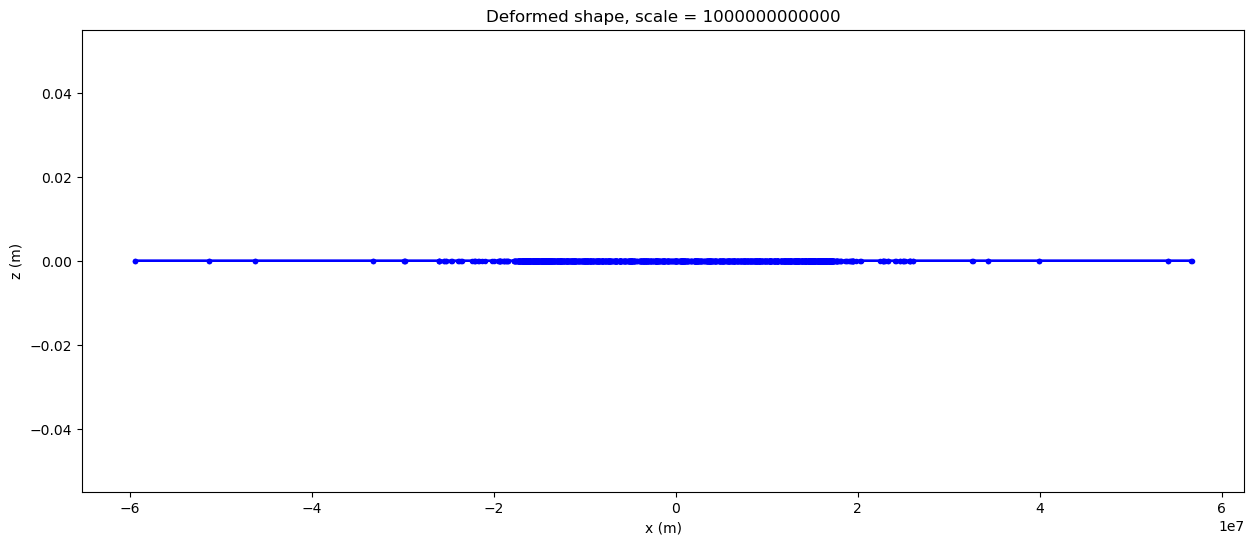

In [ ]:
# scale = 100

# x_def = NodeArr[:, 0] + scale*ux
# z_def = NodeArr[:, 2] + scale*uz

# plt.figure()
# plt.plot(NodeArr[:, 0], NodeArr[:, 2], "--", color="gray", lw=1, alpha=0.6)
# plt.plot(x_def, z_def, "o-", color="blue", ms=3, lw=1.5)
# plt.xlabel("x (m)")
# plt.ylabel("z (m)")
# plt.title("Deformed shape, scale = "+str(scale))